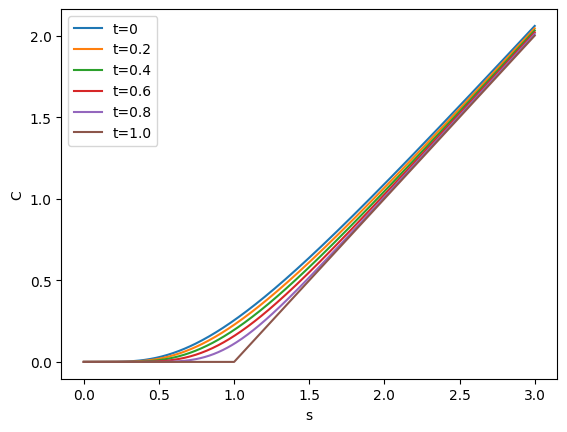

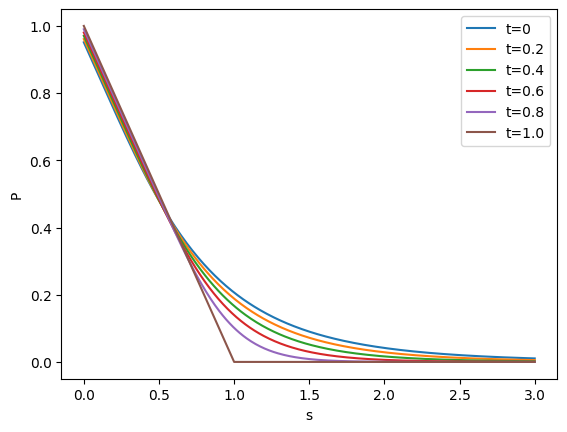

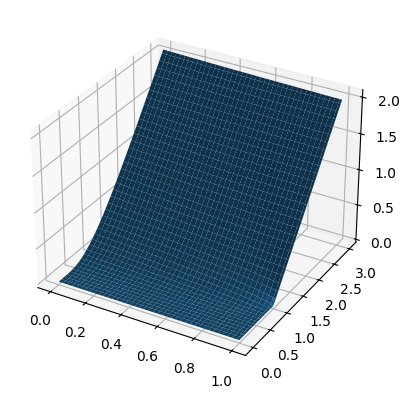

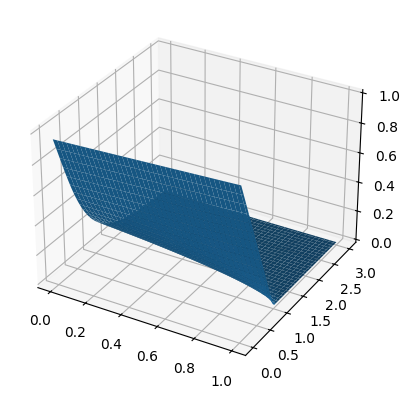

sigma  call  put
0.1 0.06804957708822157 0.01927900158893553
0.2 0.10450583572185568 0.05573526022256975
0.4 0.1802295145021668 0.13145893900288086
0.6 0.255232056656095 0.20646148115680896
0.8 0.3282098246699007 0.2794392491706147
1.0 0.3984016248343717 0.3496310493350857
r  call  put
-0.02 0.22823253922125908 0.2484338792480148
0 0.23582284437790518 0.23582284437790518
0.02 0.24351455884335477 0.22371323215011008
0.05 0.255232056656095 0.20646148115680896
0.08 0.26715089192964914 0.1902672383162849
0.1 0.2752002580716967 0.1800376761076562
K  call  put
0.8 0.347515269260992 0.10849880886156338
0.9 0.29786499709702685 0.1539714791476695
1.0 0.255232056656095 0.20646148115680896
1.1 0.21877929191864137 0.26513165886942686
1.2 0.18769031579907625 0.329165625199933


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from math import erf, sqrt

def norm_cdf(x):
    x = np.asarray(x, dtype=float)
    erf_vec = np.vectorize(erf)
    return 0.5 * (1.0 + erf_vec(x / sqrt(2.0)))

def bsm(S, K, r, sigma, T, t):
    S = np.asarray(S, dtype=float)
    t = np.asarray(t, dtype=float)
    S, t = np.broadcast_arrays(S, t)
    tau = T - t
    call = np.empty_like(S)
    put = np.empty_like(S)
    matured = np.isclose(tau, 0.0)
    call[matured] = np.maximum(S[matured] - K, 0.0)
    put[matured] = np.maximum(K - S[matured], 0.0)
    alive = ~matured
    if np.any(alive):
        S_a = S[alive]
        tau_a = tau[alive]
        d1 = (np.log(S_a / K) + (r + 0.5 * sigma**2) * tau_a) / (sigma * np.sqrt(tau_a))
        d2 = d1 - sigma * np.sqrt(tau_a)
        Nd1 = norm_cdf(d1)
        Nd2 = norm_cdf(d2)
        Nmd1 = norm_cdf(-d1)
        Nmd2 = norm_cdf(-d2)
        disc = np.exp(-r * tau_a)
        call[alive] = S_a * Nd1 - K * disc * Nd2
        put[alive] = K * disc * Nmd2 - S_a * Nmd1
    return call, put

os.makedirs("plots", exist_ok=True)

T = 1.0
K = 1.0
r = 0.05
sigma = 0.6

S = np.linspace(0.0001, 3, 400)
times = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

plt.figure()
for t in times:
    C, _ = bsm(S, K, r, sigma, T, t)
    plt.plot(S, C, label=f"t={t}")
plt.legend()
plt.xlabel("s")
plt.ylabel("C")
plt.savefig("plots/call_vs_s.png")
plt.show()

plt.figure()
for t in times:
    _, P = bsm(S, K, r, sigma, T, t)
    plt.plot(S, P, label=f"t={t}")
plt.legend()
plt.xlabel("s")
plt.ylabel("P")
plt.savefig("plots/put_vs_s.png")
plt.show()

from mpl_toolkits.mplot3d import Axes3D

s = np.linspace(0.0001, 3, 80)
t = np.linspace(0, T, 80)
Sg, Tg = np.meshgrid(s, t)
C, P = bsm(Sg, K, r, sigma, T, Tg)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(Tg, Sg, C)
plt.savefig("plots/call_surface.png")
plt.show()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(Tg, Sg, P)
plt.savefig("plots/put_surface.png")
plt.show()

sigma_vals = [0.1,0.2,0.4,0.6,0.8,1.0]
print("sigma  call  put")
for sig in sigma_vals:
    C,P = bsm(1.0, K, r, sig, T, 0)
    print(sig, float(C), float(P))

r_vals = [-0.02,0,0.02,0.05,0.08,0.1]
print("r  call  put")
for rr in r_vals:
    C,P = bsm(1.0, K, rr, sigma, T, 0)
    print(rr, float(C), float(P))

K_vals = [0.8,0.9,1.0,1.1,1.2]
print("K  call  put")
for kk in K_vals:
    C,P = bsm(1.0, kk, r, sigma, T, 0)
    print(kk, float(C), float(P))

In [2]:
import shutil
from google.colab import files

shutil.make_archive('plots', 'zip', 'plots')
files.download('plots.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>